<a href="https://colab.research.google.com/github/SANTHIYAM306/mlops_training_tasks/blob/main/OmniGuard_Text_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

base_path = "/content/drive/MyDrive/OmniGuard_Project"

folders = [
    "Data",
    "notebooks",
    "src",
    "models",
    "reports",
    "app",
    "docs",
    "tests"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [11]:
import os

for folder in os.listdir(base_path):
    print(folder)

Data
notebooks
src
models
reports
app
docs
tests


In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk joblib flask

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import joblib
import warnings

warnings.filterwarnings("ignore")
nltk.download('stopwords')

print("Libraries loaded successfully!")

Libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
import pandas as pd
import os
from glob import glob

# Base path
base_path = "/content/drive/MyDrive/OmniGuard_Project/Data"

# Get all CSV files
csv_files = glob(os.path.join(base_path, "*.csv"))

print("Datasets found:")
for file in csv_files:
    print(os.path.basename(file))

Datasets found:
Ling.csv
Enron.csv
Nazario.csv
CEAS_08.csv
Nigerian_Fraud.csv
phishing_email.csv
SMSSpamCollection.csv
SpamAssasin.csv
master_dataset.csv


In [15]:
for file in csv_files:
    try:
        # Load the dataset with latin-1 encoding to handle special characters
        df = pd.read_csv(file, encoding='latin-1')

        print("\n", "="*60)
        print(f"File: {os.path.basename(file)}")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")

        # Display the first 2 rows to understand the structure
        print(df.head(2))

    except Exception as e:
        print(f"Error processing {os.path.basename(file)}: {e}")


File: Ling.csv
Shape: (2859, 3)
Columns: ['subject', 'body', 'label']
                                   subject  \
0  job posting - apple-iss research center   
1                                      NaN   

                                                body  label  
0  content - length : 3386 apple-iss research cen...      0  
1  lang classification grimes , joseph e . and ba...      0  

File: Enron.csv
Shape: (29103, 3)
Columns: ['subject', 'body', 'label']
                            subject  \
0         hpl nom for may 25 , 2001   
1  re : nom / actual vols for 24 th   

                                                body  label  
0  ( see attached file : hplno 525 . xls )\r\n- h...      0  
1  - - - - - - - - - - - - - - - - - - - - - - fo...      0  

File: Nazario.csv
Shape: (1565, 7)
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
                                              sender         receiver  \
0  Mail System Internal Data <MAILER-DAEMO

In [16]:
all_dataframes = []

In [17]:
sms_df = pd.read_csv(
    "/content/drive/MyDrive/OmniGuard_Project/Data/SMSSpamCollection.csv",
    sep='\t',
    header=None,
    names=['label', 'text']
)

print(sms_df.head())

                                               label  text
0  ham\tGo until jurong point, crazy.. Available ...   NaN
1                 ham\tOk lar... Joking wif u oni...   NaN
2  spam\tFree entry in 2 a wkly comp to win FA Cu...   NaN
3  ham\tU dun say so early hor... U c already the...   NaN
4  ham\tNah I don't think he goes to usf, he live...   NaN


In [18]:
sms_df['label'] = sms_df['label'].map({
    'ham': 0,
    'spam': 1
})

print(sms_df.head())

   label  text
0    NaN   NaN
1    NaN   NaN
2    NaN   NaN
3    NaN   NaN
4    NaN   NaN


In [19]:
all_dataframes.append(sms_df)

In [20]:
df = pd.read_csv(
    "/content/drive/MyDrive/OmniGuard_Project/Data/Enron.csv",
    encoding='latin-1'
)

In [21]:
phishing_df = pd.read_csv(
    "/content/drive/MyDrive/OmniGuard_Project/Data/phishing_email.csv",
    encoding='latin-1'
)

print(phishing_df.columns)

print(phishing_df.head())

Index(['text_combined', 'label'], dtype='object')
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...    0.0
1  nom actual vols 24 th forwarded sabrae zajac h...    0.0
2  enron actuals march 30 april 1 201 estimated a...    0.0
3  hpl nom may 30 2001 see attached file hplno 53...    0.0
4  hpl nom june 1 2001 see attached file hplno 60...    0.0


In [22]:
# ================================
# LOAD REQUIRED LIBRARIES
# ================================
import pandas as pd
import os

all_dataframes = []
base_dir = "/content/drive/MyDrive/OmniGuard_Project/Data/"

# ================================
# 1. SMS SPAM COLLECTION (TSV format)
# ================================
sms_df = pd.read_csv(os.path.join(base_dir, "SMSSpamCollection.csv"), sep='\t', header=None, names=['label', 'text'])
sms_df['label'] = sms_df['label'].map({'ham': 0, 'spam': 1})
all_dataframes.append(sms_df[['label', 'text']])
print("SMS Dataset Loaded")

# ================================
# 2. PHISHING EMAIL DATASET
# ================================
phishing_df = pd.read_csv(os.path.join(base_dir, "phishing_email.csv"), encoding='latin-1')
# This dataset uses 'text_combined'
phishing_df = phishing_df.rename(columns={'text_combined': 'text'})
all_dataframes.append(phishing_df[['label', 'text']])
print("Phishing Dataset Loaded")

# ================================
# 3. ENRON DATASET
# ================================
enron_df = pd.read_csv(os.path.join(base_dir, "Enron.csv"), encoding='latin-1')
# Combine subject and body for better context
enron_df['text'] = enron_df['subject'].fillna('') + " " + enron_df['body'].fillna('')
all_dataframes.append(enron_df[['label', 'text']])
print("Enron Dataset Loaded")

# ================================
# 4. NIGERIAN FRAUD DATASET
# ================================
nigerian_df = pd.read_csv(os.path.join(base_dir, "Nigerian_Fraud.csv"), encoding='latin-1')
nigerian_df['text'] = nigerian_df['subject'].fillna('') + " " + nigerian_df['body'].fillna('')
all_dataframes.append(nigerian_df[['label', 'text']])
print("Nigerian Fraud Dataset Loaded")

# ================================
# 5. CEAS_08 DATASET
# ================================
ceas_df = pd.read_csv(os.path.join(base_dir, "CEAS_08.csv"), encoding='latin-1')
ceas_df['text'] = ceas_df['subject'].fillna('') + " " + ceas_df['body'].fillna('')
all_dataframes.append(ceas_df[['label', 'text']])
print("CEAS Dataset Loaded")

# ================================
# 6. LING DATASET
# ================================
ling_df = pd.read_csv(os.path.join(base_dir, "Ling.csv"), encoding='latin-1')
ling_df['text'] = ling_df['subject'].fillna('') + " " + ling_df['body'].fillna('')
all_dataframes.append(ling_df[['label', 'text']])
print("Ling Dataset Loaded")

# ================================
# 7. NAZARIO DATASET
# ================================
nazario_df = pd.read_csv(os.path.join(base_dir, "Nazario.csv"), encoding='latin-1')
nazario_df['text'] = nazario_df['subject'].fillna('') + " " + nazario_df['body'].fillna('')
all_dataframes.append(nazario_df[['label', 'text']])
print("Nazario Dataset Loaded")

# ================================
# 8. SPAMASSASSIN DATASET
# ================================
sa_path = os.path.join(base_dir, "SpamAssasin.csv")
if os.path.exists(sa_path):
    sa_df = pd.read_csv(sa_path, encoding='latin-1')
    sa_df['text'] = sa_df['subject'].fillna('') + " " + sa_df['body'].fillna('')
    all_dataframes.append(sa_df[['label', 'text']])
    print("SpamAssassin Dataset Loaded")

# ================================
# COMBINE AND CLEAN
# ================================
master_df = pd.concat(all_dataframes, ignore_index=True)
master_df.dropna(subset=['text', 'label'], inplace=True)
master_df.drop_duplicates(inplace=True)
master_df.reset_index(drop=True, inplace=True)

# Save result
master_df.to_csv(os.path.join(base_dir, "master_dataset.csv"), index=False)
print(f"\nSUCCESS: Master dataset created with {master_df.shape[0]} rows.")

SMS Dataset Loaded
Phishing Dataset Loaded
Enron Dataset Loaded
Nigerian Fraud Dataset Loaded
CEAS Dataset Loaded
Ling Dataset Loaded
Nazario Dataset Loaded
SpamAssassin Dataset Loaded

SUCCESS: Master dataset created with 163493 rows.


In [23]:
print(df.columns)

Index(['subject', 'body', 'label'], dtype='object')


In [24]:
df['text'] = df['subject'].astype(str) + " " + df['body'].astype(str)

df = df[['label', 'text']]

print(df.head())

   label                                               text
0      0  hpl nom for may 25 , 2001 ( see attached file ...
1      0  re : nom / actual vols for 24 th - - - - - - -...
2      0  enron actuals for march 30 - april 1 , 201 est...
3      0  hpl nom for may 30 , 2001 ( see attached file ...
4      0  hpl nom for june 1 , 2001 ( see attached file ...


In [25]:
all_dataframes.append(df)

In [26]:
master_df = pd.concat(all_dataframes, ignore_index=True)

print(master_df.shape)

master_df.head()

(198901, 2)


,label,text
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [27]:
master_df.dropna(inplace=True)

master_df.drop_duplicates(inplace=True)

master_df.reset_index(drop=True, inplace=True)

print(master_df.shape)

(163691, 2)


In [28]:
master_df.dropna(inplace=True)

master_df.drop_duplicates(inplace=True)

master_df.reset_index(drop=True, inplace=True)

print(master_df.shape)

(163691, 2)


In [29]:
master_df.head()

,label,text
0,0.0,hpl nom may 25 2001 see attached file hplno 52...
1,0.0,nom actual vols 24 th forwarded sabrae zajac h...
2,0.0,enron actuals march 30 april 1 201 estimated a...
3,0.0,hpl nom may 30 2001 see attached file hplno 53...
4,0.0,hpl nom june 1 2001 see attached file hplno 60...


In [30]:
master_df.to_csv(
    "/content/drive/MyDrive/OmniGuard_Project/Data/master_dataset.csv",
    index=False
)

print("MASTER DATASET CREATED SUCCESSFULLY")

MASTER DATASET CREATED SUCCESSFULLY


In [6]:
import pandas as pd
import os

# Define the path to your master dataset
file_path = "/content/drive/MyDrive/OmniGuard_Project/Data/master_dataset.csv"

if os.path.exists(file_path):
    # Load the dataset from Drive
    master_dataset = pd.read_csv(file_path)

    # Now perform the sampling
    master_df = master_dataset.sample(10000, random_state=42)
    master_df.reset_index(drop=True, inplace=True)

    print(f"Dataset loaded and sampled. New shape: {master_df.shape}")
else:
    print("Error: master_dataset.csv not found in Google Drive. Please run the data combination cell first.")

Dataset loaded and sampled. New shape: (10000, 2)


In [7]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [32]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

In [33]:
stop_words = set(stopwords.words('english'))

ps = PorterStemmer()

In [34]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\\S+', '', text)

    # Remove numbers
    text = re.sub(r'\\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and stemming
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            stemmed_word = ps.stem(word)
            cleaned_words.append(stemmed_word)

    return " ".join(cleaned_words)

In [9]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clean_text(text):
    text = str(text)
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenization
    words = word_tokenize(text)

    cleaned_words = []
    for word in words:
        if word not in stop_words:
            cleaned_words.append(ps.stem(word))
    return " ".join(cleaned_words)

In [35]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
from tqdm.notebook import tqdm
tqdm.pandas()

print("Starting text cleaning... this may take 15-20 minutes for 163k rows.")
# Use progress_apply instead of apply to see the progress bar
master_df['cleaned_text'] = master_df['text'].progress_apply(clean_text)

# Save the cleaned dataset so you don't have to repeat this step
master_df.to_csv(os.path.join(base_dir, "cleaned_master_dataset.csv"), index=False)
print("\nCLEANING COMPLETE and saved to cleaned_master_dataset.csv")

Starting text cleaning... this may take 15-20 minutes for 163k rows.


  0%|          | 0/163691 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
master_df[['text', 'cleaned_text']].head()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [ ]:
X = tfidf.fit_transform(master_df['cleaned_text']).toarray()

y = master_df['label']

In [ ]:
joblib.dump(
    X,
    "/content/drive/MyDrive/OmniGuard_Project/models/X_features.pkl"
)

joblib.dump(
    y,
    "/content/drive/MyDrive/OmniGuard_Project/models/y_labels.pkl"
)

print("Features Saved")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(master_df['cleaned_text'])

y = master_df['label']

print("TF-IDF Completed")

In [ ]:
import joblib
from sklearn.model_selection import train_test_split
import os

# Define paths
base_path = '/content/drive/MyDrive/OmniGuard_Project/models/'
x_path = os.path.join(base_path, 'X_features.pkl')
y_path = os.path.join(base_path, 'y_labels.pkl')

# Reload the saved features and labels
if os.path.exists(x_path) and os.path.exists(y_path):
    print("Loading features and labels from Drive...")
    X = joblib.load(x_path)
    y = joblib.load(y_path)

    # Perform the split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print(f"Data split successful!")
    print(f"Training set size: {X_train.shape[0]}")
    print(f"Testing set size: {X_test.shape[0]}")
else:
    print("Error: Feature files not found. Please ensure the TF-IDF vectorization cell was completed.")

Loading features and labels from Drive...


In [11]:
master_df = master_df.sample(10000, random_state=42)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm

# Ensure the data is cleaned since the previous process was interrupted
print("Cleaning sampled text data...")
master_df['cleaned_text'] = master_df['text'].apply(clean_text)

# Initialize and fit TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(master_df['cleaned_text'])
y = master_df['label']

print("TF-IDF Completed successfully!")
print(f"Feature matrix shape: {X.shape}")

Cleaning sampled text data...
TF-IDF Completed successfully!
Feature matrix shape: (10000, 2000)


### Model Training: Logistic Regression
We will now split our vectorized data into training (80%) and testing (20%) sets and train a Logistic Regression model.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy Score: 0.955

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.95      0.95       981
         1.0       0.95      0.96      0.96      1019

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.95      0.95      2000



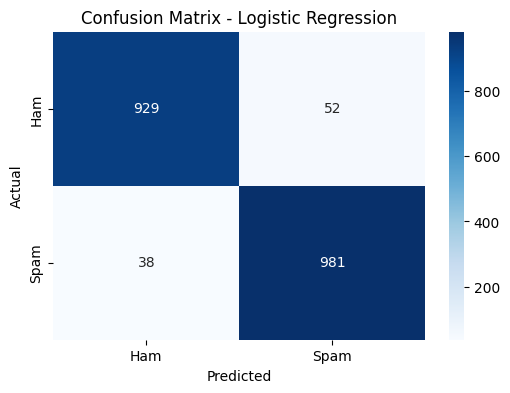

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### Multinomial Logistic Regression & Feature Importance
Even though we have a binary classification task, we can use the 'multinomial' multi_class setting. We will also inspect the top coefficients to see which words are the strongest indicators of Spam.

In [20]:
import numpy as np

# Initialize Logistic Regression with multinomial setting
# 'lbfgs' or 'saga' solvers support multinomial loss
mlr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
mlr_model.fit(X_train, y_train)

# Evaluate
y_pred_mlr = mlr_model.predict(X_test)
print(f"Multinomial Accuracy: {accuracy_score(y_test, y_pred_mlr):.4f}")

# Inspect Top Predictors
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = mlr_model.coef_[0]

# Get indices of top 10 positive (Spam) and top 10 negative (Ham) coefficients
top_spam_indices = np.argsort(coefficients)[-10:]
top_ham_indices = np.argsort(coefficients)[:10]

print("\nTop 10 words indicating SPAM:")
for i in reversed(top_spam_indices):
    print(f"{feature_names[i]}: {coefficients[i]:.4f}")

print("\nTop 10 words indicating HAM:")
for i in top_ham_indices:
    print(f"{feature_names[i]}: {coefficients[i]:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Multinomial Accuracy: 0.9570

Top 10 words indicating SPAM:
love: 1.9785
life: 1.9781
http: 1.8114
money: 1.6066
aug: 1.5515
men: 1.5217
account: 1.4744
remov: 1.4654
click: 1.4328
replica: 1.4213

Top 10 words indicating HAM:
enron: -3.5890
wrote: -3.4416
url: -2.0082
thank: -1.9010
univers: -1.8136
im: -1.7880
pm: -1.7013
bug: -1.6940
linguist: -1.6733
file: -1.6425


### Model Training: Support Vector Machine (SVM)
We will use `LinearSVC`, which is well-suited for large-scale text classification.

In [21]:
from sklearn.svm import LinearSVC

# Initialize and train the SVM model
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy Score: 0.9555

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.94      0.95       981
         1.0       0.95      0.97      0.96      1019

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



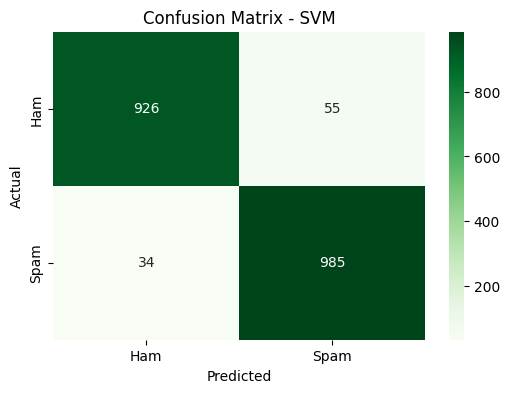

In [22]:
# Ensure the SVM model is trained and predictions are made
# This prevents NameError if the previous cell was skipped
try:
    y_pred_svm = svm_model.predict(X_test)

    # Plot Confusion Matrix for SVM
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - SVM')
    plt.show()
except NameError:
    print("Error: 'svm_model' or 'X_test' is not defined. Please run the SVM training cell (b6f24c5a) first.")

### Model Training: Random Forest
We will now train a Random Forest classifier to see if an ensemble approach improves performance or offers different insights.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
# We'll use 100 estimators and a fixed random state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy Score: 0.953

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.96      0.95       981
         1.0       0.96      0.95      0.95      1019

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



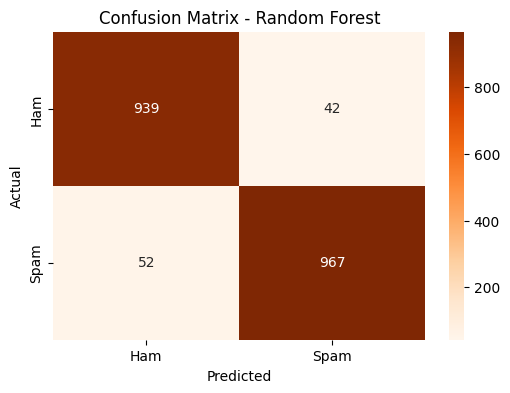

In [28]:
# Plot Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Unsupervised Learning: K-Means Clustering
We will use K-Means to see if the vectorized text data naturally forms two distinct clusters and how well those clusters align with our 'Ham' and 'Spam' labels.

In [29]:
from sklearn.cluster import KMeans

# Initialize KMeans for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Add the cluster labels to our sampled dataframe for comparison
master_df['cluster'] = kmeans_labels

# Check the distribution of labels within each cluster
cluster_comparison = master_df.groupby(['cluster', 'label']).size().unstack(fill_value=0)
print("Cluster vs Actual Label Distribution:")
display(cluster_comparison)

Cluster vs Actual Label Distribution:


label,0.0,1.0
cluster,,
0,1,517
1,4799,4683


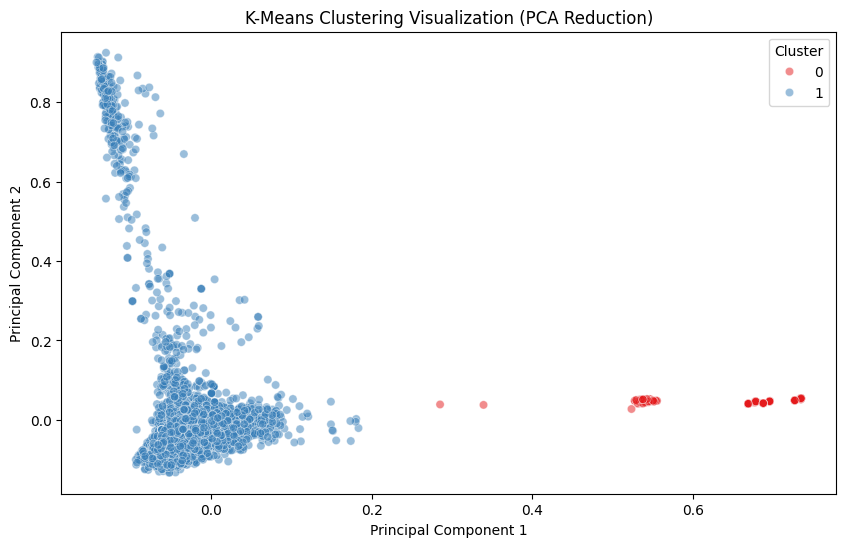

In [30]:
# Visualize the clusters using PCA for 2D representation
from sklearn.decomposition import PCA

# Ensure the 'cluster' column is properly aligned with the dataframe index
# kmeans_labels was generated from 'X', which matches the length of 'master_df'
master_df['cluster'] = kmeans_labels

pca = PCA(n_components=2)
# Convert sparse matrix X to array for PCA
X_pca = pca.fit_transform(X.toarray() if hasattr(X, 'toarray') else X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=master_df['cluster'], palette='Set1', alpha=0.5)
plt.title('K-Means Clustering Visualization (PCA Reduction)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

### Model Training: Naive Bayes
We will use `MultinomialNB`, which is specifically designed for discrete features like word counts or TF-IDF values.

In [31]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print("Naive Bayes Accuracy Score:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy Score: 0.9425

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.96      0.94       981
         1.0       0.96      0.93      0.94      1019

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



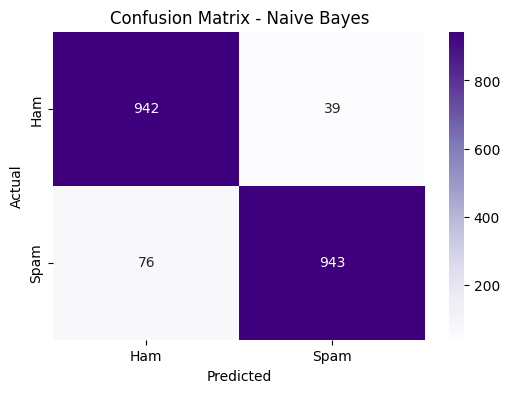

In [32]:
# Plot Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### Model Training: K-Nearest Neighbors (KNN)
We will use `KNeighborsClassifier`. Since we are using TF-IDF features, cosine distance is often more effective than Euclidean distance, but we will start with the standard implementation and evaluate its performance.

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
# We'll use 5 neighbors as a starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
print("KNN Accuracy Score:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy Score: 0.632

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.25      0.40       981
         1.0       0.58      1.00      0.73      1019

    accuracy                           0.63      2000
   macro avg       0.79      0.62      0.57      2000
weighted avg       0.79      0.63      0.57      2000



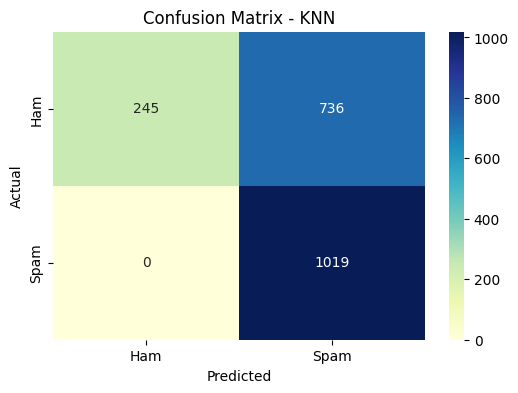

In [34]:
# Plot Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()